In [2]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load GSS dataset
df_cs_abo = pd.read_csv('data/GSS/gss_abt_cs_abortion.csv')
df_cs_homosex = pd.read_csv('data/GSS/gss_abt_cs_homosex.csv')
df_pl_abo = pd.read_csv('data/GSS/gss_abt_panel_abortion.csv')
df_pl_homosex = pd.read_csv('data/GSS/gss_abt_panel_homosex.csv')

In [5]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 11), (17576, 12), (13647, 11))

In [6]:
# Convert year 2021 to 2020
df_cs_abo.loc[df_cs_abo['year'] == 2021, 'year'] = 2020
df_cs_homosex.loc[df_cs_homosex['year'] == 2021, 'year'] = 2020
df_pl_abo.loc[df_pl_abo['year'] == 2021, 'year'] = 2020
df_pl_homosex.loc[df_pl_homosex['year'] == 2021, 'year'] = 2020

In [7]:
ABORT4 = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

GROUP_COLS_4 = ["generation","gender","race","edu_level"]
GROUP_COLS_3 = ["generation","gender","race"]
GROUP_COLS_2 = ["generation","gender"]
GROUP_COLS_1 = ["generation"]

ABORT2ID = {c:i for i,c in enumerate(ABORT4)}
HOMOSEX2ID = {c:i for i,c in enumerate(HOMOSEX4)}

In [8]:
# Multinomial logistic AR analysis
from sklearn.linear_model import Ridge

# ALR helpers (reference = last category)
def alr(p, eps=1e-8):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0)
    p = p / p.sum()
    ref = p[-1]
    return np.log(p[:-1] / ref)

def inv_alr(u):
    u = np.asarray(u, dtype=float)
    z = np.r_[np.exp(u), 1.0]
    return z / z.sum()

# Fit AR(1) per subgroup with ridge, forecast next year
def cs_ar_fit_and_forecast(p_cs, l2=1.0, min_years=3):
    """
    p_cs: dict {((group_tuple), year) -> p (K,)}
    Returns dict {((group_tuple), year_next) -> p_hat_AR}
    """
    by_group = {}
    for (g,y), p in p_cs.items():
        by_group.setdefault(g, []).append(int(y))

    forecasts = {}
    for g, ys in by_group.items():
        ys = sorted(ys)
        if len(ys) < min_years:
            # too few years: fallback to persistence p_{t+1} = p_t
            for i in range(1, len(ys)):
                y_prev, y = ys[i-1], ys[i]
                forecasts[(g, y)] = p_cs[(g, y_prev)]
            continue

        # Build (X=u_{t-1}, Y=u_t) in ALR space
        X_list, Y_list, targets = [], [], []
        for i in range(1, len(ys)):
            y_prev, y = ys[i-1], ys[i]
            u_prev = alr(p_cs[(g, y_prev)])
            u_curr = alr(p_cs[(g, y)])
            X_list.append(np.r_[1.0, u_prev])   # intercept + u_{t-1}
            Y_list.append(u_curr)
            targets.append((g, y))
        X = np.vstack(X_list)        # [T-1, 1+(K-1)]
        Y = np.vstack(Y_list)        # [T-1, (K-1)]

        # Fit separate Ridge for each ALR dimension (small T)
        coefs = []
        for k in range(Y.shape[1]):
            reg = Ridge(alpha=l2, fit_intercept=False)  # intercept already in X
            reg.fit(X, Y[:,k])
            coefs.append(reg.coef_)
        B = np.vstack(coefs)  # shape [(K-1) x (K)]

        # Forecast each step from previous observed (one-step ahead backtest)
        for i in range(1, len(ys)):
            y_prev, y = ys[i-1], ys[i]
            u_prev = alr(p_cs[(g, y_prev)])
            x = np.r_[1.0, u_prev]             # [K]
            u_hat = B @ x                      # [K-1]
            p_hat = inv_alr(u_hat)
            forecasts[(g, y)] = p_hat

    return forecasts

In [9]:
# Markov model
def row_normalize(M, alpha=0.25):
    M = np.asarray(M, dtype=float)
    M = M + alpha
    rs = M.sum(axis=1, keepdims=True)
    return M / np.clip(rs, 1e-12, None)

def panel_markov_forecast(p_cs, C, Nfrom, alpha=0.25):
    """
    p_cs: {((g), y) -> p}
    C, Nfrom: panel counts keyed by ((g_tuple), t, Δ)
    Returns dict {((g), y) -> p_hat_MC} for years that have (g, y-Δ) and panel info.
    """
    forecasts = {}
    # Build a lookup of T per (g, Δ, anchor t) and also a pooled (g, Δ) if you want to pool across t
    T_lookup = {}
    for key, mat in C.items():
        g, t, Δ = key
        T = row_normalize(mat, alpha=alpha)
        T_lookup[(g, t, Δ)] = T


    # Option: pooled T over t for a given (g, Δ) to improve stability
    pooled_T = {}
    for (g,t,Δ), T in T_lookup.items():
        pooled_T.setdefault((g, Δ), []).append(T)
    pooled_T = {k: np.mean(v, axis=0) for k,v in pooled_T.items()}

    # Forecast wherever possible
    by_group = {}
    for (g,y), _ in p_cs.items():
        by_group.setdefault(g, []).append(int(y))
    for g, ys in by_group.items():
        ys = sorted(ys)
        for i in range(1, len(ys)):
            y_prev, y = ys[i-1], ys[i]
            Δ = y - y_prev
            p_prev = p_cs[(g, y_prev)]
            # prefer anchored T at (g, t=y_prev), else pooled over t for (g, Δ)
            T = T_lookup.get((g, y_prev, Δ))
            if T is None:
                T = pooled_T.get((g, Δ))
            if T is None:
                continue  # no panel info for this gap
            p_hat = p_prev @ T
            p_hat = p_hat / np.clip(p_hat.sum(), 1e-12, None)
            forecasts[(g, y)] = p_hat
    return forecasts

In [12]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_4
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs = {}
effN_cs = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_4):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs[(g_vals, y)] = p
        effN_cs[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id in df_pl_abo.groupby("yearid"):
    df_id = df_id.sort_values("year")
    # collapse duplicates per year if any
    df_id = df_id.drop_duplicates(subset=["year"], keep="last")
    years = df_id["year"].values.tolist()
    atts  = df_id["abortion_att4"].values.tolist()
    wgts  = df_id["w"].values.astype(float).tolist()
    gens  = df_id["generation"].values.tolist()
    gend  = df_id["gender"].values.tolist()
    race  = df_id["race"].values.tolist()
    edu = df_id["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1 and len(set(race))==1 and len(set(edu))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0], gend[0], race[0], edu[0])
    
    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C[(g,t,Δ)][ai, aj] += w
        Nfrom[(g,t,Δ)][ai] += w

In [13]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR = cs_ar_fit_and_forecast(p_cs, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC = panel_markov_forecast(p_cs, C, Nfrom, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_4, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs[(g, y)]
        if (g, y) in p_hat_AR:
            rec["JSD_AR"] = float(jsd(p_hat_AR[(g,y)], p_obs))
        if (g, y) in p_hat_MC:
            rec["JSD_MC"] = float(jsd(p_hat_MC[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,gender,race,edu_level,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.028272,0.346626
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.357902,0.064341
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,0.398768,0.229432
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,0.102151,0.196799
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,0.117836,0.055920


In [14]:
# Load our predicted values (p-hat)
df_pred = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g4.csv")

# Convert year 2021 to 2020
df_pred.loc[df_pred['year'] == 2021, 'year'] = 2020
df_pred.loc[df_pred['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred['year_t'] = df_pred['year_prev']
df_pred['year_t1'] = df_pred['year']

df_pred.head(2)

,generation,gender,race,edu_level,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.156398,0.409694,0.208237,0.225671,...,0.0,0.079963,0.000000,0.920037,0.099381,0.176772,0.248766,0.004162,2006,2008
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.000000,0.079963,0.000000,0.920037,...,0.0,0.209616,0.266931,0.523453,0.066700,0.176592,0.043720,0.131728,2008,2010


In [15]:
# Build p_hat from df_pred
def get_group_cols(group=GROUP_COLS_4):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in ABORT4:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_tllm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, tllm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, tllm_hat, tllm_margin, tllm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in tllm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(ABORT4):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in tllm_series:
                vecs = t_series.get(s, {})
                rec[f"tllm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_tllm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, tllm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs T-LLM.
    tllm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_tllm(g, p_cs, p_hat_AR, p_hat_MC, bt, tllm_series=tllm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs AR vs MC vs T-LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(CANON4):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add T-LLM lines
        color_cycle_added = False
        for s in tllm_series:
            ax.plot(d["year"], d[f"tllm_{s}"], marker="^", linestyle=":",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(tllm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

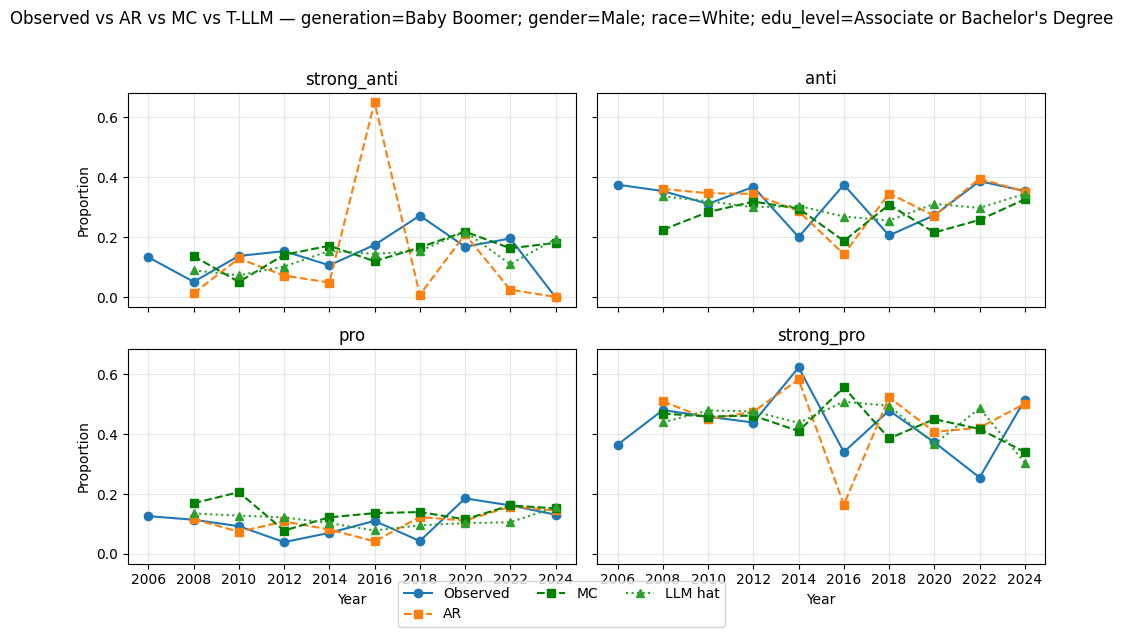

In [19]:
# candidates = list_groups_sorted_by_coverage(p_cs, min_years=3)
# g_example = candidates[0] if candidates else next(iter({g for (g,_) in p_cs}))
# Show ensemble 'hat' only:
CANON4 = ABORT4
g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_tllm(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, tllm_series=("hat",))



In [23]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_4):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle="--", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

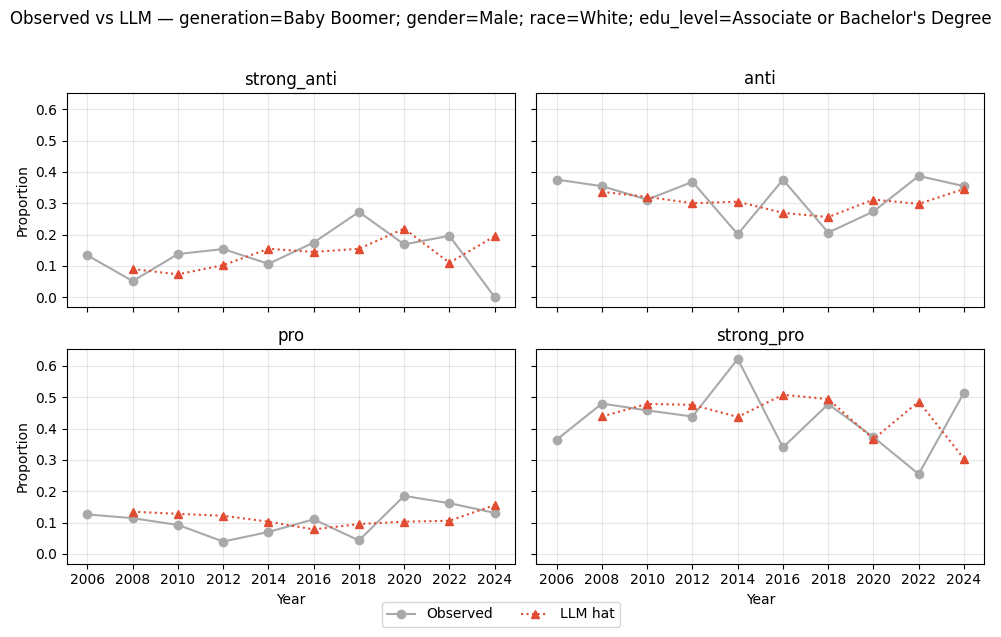

In [24]:
g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, llm_series=("hat",))

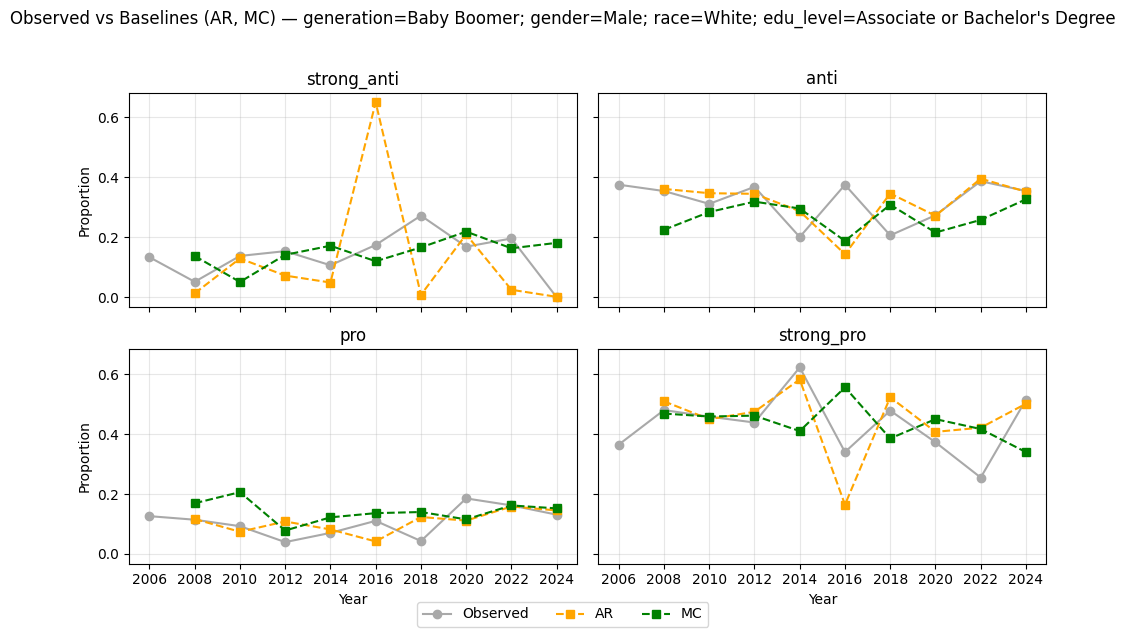

In [25]:
g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_baselines(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, llm_series=("hat",))